In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\rithi\anaconda3\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df=pd.read_csv(r'LI-Small_Trans_new.csv')
df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:02,70,10042B660,22661,805F7F2B0,70831.64,US Dollar,70831.64,US Dollar,Cash,1
1,2022/09/01 00:19,70,10042B660,212996,80609B4C0,33705.47,US Dollar,33705.47,US Dollar,Cash,1
2,2022/09/01 00:01,70,10042B660,11305,807861770,1097976.27,US Dollar,1097976.27,US Dollar,Cash,1
3,2022/09/01 00:00,11968,815630C40,249349,815635220,892.33,US Dollar,892.33,US Dollar,ACH,1
4,2022/09/01 00:25,70,10042B660,11968,816F93AF0,1808.14,US Dollar,1808.14,US Dollar,Cheque,1
...,...,...,...,...,...,...,...,...,...,...,...
72765,2022/09/05 12:55,113,8000B2F90,19,810BDE890,3707894.61,Mexican Peso,3707894.61,Mexican Peso,Cheque,0
72766,2022/09/02 23:07,12204,8061A7620,21828,80B1EA2C0,4454.01,US Dollar,4454.01,US Dollar,Cheque,0
72767,2022/09/06 11:24,23486,80982B510,25892,80AC15310,19211.82,Rupee,19211.82,Rupee,Cash,0
72768,2022/09/02 17:29,70,10042B660,140797,810023350,5392.93,US Dollar,5392.93,US Dollar,Cheque,0


In [3]:
df.shape

(72770, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72770 entries, 0 to 72769
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           72770 non-null  str    
 1   From Bank           72770 non-null  int64  
 2   Account             72770 non-null  str    
 3   To Bank             72770 non-null  int64  
 4   Account.1           72770 non-null  str    
 5   Amount Received     72770 non-null  float64
 6   Receiving Currency  72770 non-null  str    
 7   Amount Paid         72770 non-null  float64
 8   Payment Currency    72770 non-null  str    
 9   Payment Format      72770 non-null  str    
 10  Is Laundering       72770 non-null  int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 10.0 MB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

In [7]:
df.describe(include='all')

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
count,72770,72770.000000,72770,72770.000000,72770,7.277000e+04,72770,7.277000e+04,72770,72770,72770.000000
unique,13952,NaN,53641,NaN,63868,NaN,15,NaN,15,7,NaN
top,2022/09/01 00:03,NaN,10042B660,NaN,10042B660,NaN,US Dollar,NaN,US Dollar,Cheque,NaN
freq,165,NaN,2577,NaN,19,NaN,26820,NaN,26989,25548,NaN
mean,NaN,58051.419857,NaN,83339.912890,NaN,2.397022e+06,NaN,2.097077e+06,NaN,NaN,0.048990
std,NaN,89343.023046,NaN,90385.026742,NaN,9.187616e+07,NaN,8.148166e+07,NaN,NaN,0.215849
min,NaN,0.000000,NaN,0.000000,NaN,1.000000e-06,NaN,1.000000e-06,NaN,NaN,0.000000
25%,NaN,216.000000,NaN,10920.000000,NaN,1.865075e+02,NaN,1.875100e+02,NaN,NaN,0.000000
50%,NaN,13821.000000,NaN,29154.000000,NaN,1.506245e+03,NaN,1.507570e+03,NaN,NaN,0.000000
75%,NaN,72360.000000,NaN,145591.000000,NaN,1.212705e+04,NaN,1.207994e+04,NaN,NaN,0.000000


In [8]:
df['Timestamp'].min(),df['Timestamp'].max()

('2022/09/01 00:00', '2022/09/17 15:28')

In [9]:
df.describe(include=object)

C:\Users\rithi\AppData\Local\Temp\ipykernel_8452\3998025828.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=object)


,Timestamp,Account,Account.1,Receiving Currency,Payment Currency,Payment Format
count,72770,72770,72770,72770,72770,72770
unique,13952,53641,63868,15,15,7
top,2022/09/01 00:03,10042B660,10042B660,US Dollar,US Dollar,Cheque
freq,165,2577,19,26820,26989,25548


In [10]:
df['Payment Currency'].value_counts()

Payment Currency
US Dollar            26989
Euro                 16971
Yuan                  4946
Rupee                 3532
Bitcoin               3139
Saudi Riyal           2706
Australian Dollar     2258
Yen                   2132
Brazil Real           2060
Canadian Dollar       1920
Shekel                1816
Swiss Franc           1437
UK Pound              1056
Ruble                  932
Mexican Peso           876
Name: count, dtype: int64

### Changing the Data Types

In [11]:
df['From Bank']=df['From Bank'].astype(object)
df['To Bank']=df['To Bank'].astype(object)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72770 entries, 0 to 72769
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           72770 non-null  str    
 1   From Bank           72770 non-null  object 
 2   Account             72770 non-null  str    
 3   To Bank             72770 non-null  object 
 4   Account.1           72770 non-null  str    
 5   Amount Received     72770 non-null  float64
 6   Receiving Currency  72770 non-null  str    
 7   Amount Paid         72770 non-null  float64
 8   Payment Currency    72770 non-null  str    
 9   Payment Format      72770 non-null  str    
 10  Is Laundering       72770 non-null  int64  
dtypes: float64(2), int64(1), object(2), str(6)
memory usage: 10.0+ MB


In [13]:
df['Timestamp']=pd.to_datetime(df['Timestamp'])

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72770 entries, 0 to 72769
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Timestamp           72770 non-null  datetime64[us]
 1   From Bank           72770 non-null  object        
 2   Account             72770 non-null  str           
 3   To Bank             72770 non-null  object        
 4   Account.1           72770 non-null  str           
 5   Amount Received     72770 non-null  float64       
 6   Receiving Currency  72770 non-null  str           
 7   Amount Paid         72770 non-null  float64       
 8   Payment Currency    72770 non-null  str           
 9   Payment Format      72770 non-null  str           
 10  Is Laundering       72770 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(1), object(2), str(5)
memory usage: 8.9+ MB


In [15]:
df['Hour']=df['Timestamp'].dt.hour
df['Dayofweek']=df['Timestamp'].dt.dayofweek

In [16]:
df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Hour,Dayofweek
0,2022-09-01 00:02:00,70,10042B660,22661,805F7F2B0,70831.64,US Dollar,70831.64,US Dollar,Cash,1,0,3
1,2022-09-01 00:19:00,70,10042B660,212996,80609B4C0,33705.47,US Dollar,33705.47,US Dollar,Cash,1,0,3
2,2022-09-01 00:01:00,70,10042B660,11305,807861770,1097976.27,US Dollar,1097976.27,US Dollar,Cash,1,0,3
3,2022-09-01 00:00:00,11968,815630C40,249349,815635220,892.33,US Dollar,892.33,US Dollar,ACH,1,0,3
4,2022-09-01 00:25:00,70,10042B660,11968,816F93AF0,1808.14,US Dollar,1808.14,US Dollar,Cheque,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72765,2022-09-05 12:55:00,113,8000B2F90,19,810BDE890,3707894.61,Mexican Peso,3707894.61,Mexican Peso,Cheque,0,12,0
72766,2022-09-02 23:07:00,12204,8061A7620,21828,80B1EA2C0,4454.01,US Dollar,4454.01,US Dollar,Cheque,0,23,4
72767,2022-09-06 11:24:00,23486,80982B510,25892,80AC15310,19211.82,Rupee,19211.82,Rupee,Cash,0,11,1
72768,2022-09-02 17:29:00,70,10042B660,140797,810023350,5392.93,US Dollar,5392.93,US Dollar,Cheque,0,17,4


In [17]:
df_equal=df['Amount Received']==df['Amount Paid']
df_equal.value_counts()

True     71767
False     1003
Name: count, dtype: int64

In [18]:
df_equal=df[df['Amount Received']!=df['Amount Paid']]
df_equal['Is Laundering'].value_counts()

Is Laundering
0    1003
Name: count, dtype: int64

In [19]:
df_equal=df['Receiving Currency']==df['Payment Currency']
df_equal.value_counts()

True     71767
False     1003
Name: count, dtype: int64

In [20]:
df_equal=df[df['Receiving Currency']!=df['Payment Currency']]
df_equal['Is Laundering'].value_counts()

Is Laundering
0    1003
Name: count, dtype: int64

In [21]:
df.drop(columns=['Timestamp','Account','Account.1','Amount Received','Receiving Currency'],inplace=True)

In [22]:
df

,From Bank,To Bank,Amount Paid,Payment Currency,Payment Format,Is Laundering,Hour,Dayofweek
0,70,22661,70831.64,US Dollar,Cash,1,0,3
1,70,212996,33705.47,US Dollar,Cash,1,0,3
2,70,11305,1097976.27,US Dollar,Cash,1,0,3
3,11968,249349,892.33,US Dollar,ACH,1,0,3
4,70,11968,1808.14,US Dollar,Cheque,1,0,3
...,...,...,...,...,...,...,...,...
72765,113,19,3707894.61,Mexican Peso,Cheque,0,12,0
72766,12204,21828,4454.01,US Dollar,Cheque,0,23,4
72767,23486,25892,19211.82,Rupee,Cash,0,11,1
72768,70,140797,5392.93,US Dollar,Cheque,0,17,4


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72770 entries, 0 to 72769
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   From Bank         72770 non-null  object 
 1   To Bank           72770 non-null  object 
 2   Amount Paid       72770 non-null  float64
 3   Payment Currency  72770 non-null  str    
 4   Payment Format    72770 non-null  str    
 5   Is Laundering     72770 non-null  int64  
 6   Hour              72770 non-null  int32  
 7   Dayofweek         72770 non-null  int32  
dtypes: float64(1), int32(2), int64(1), object(2), str(2)
memory usage: 4.9+ MB


### Data Preprocesing

In [24]:
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [25]:
cat=['From Bank','To Bank','Payment Currency','Payment Format']
num=['Amount Paid','Hour','Dayofweek']

In [26]:
preprocessor=ColumnTransformer([('Scaling',MinMaxScaler(),num),
                               ('encoding',OneHotEncoder(drop='first',handle_unknown='ignore'),cat)],
                              remainder='drop')

In [27]:
x=df.drop(['Is Laundering'],axis=1)
y=df['Is Laundering']

In [28]:
x

,From Bank,To Bank,Amount Paid,Payment Currency,Payment Format,Hour,Dayofweek
0,70,22661,70831.64,US Dollar,Cash,0,3
1,70,212996,33705.47,US Dollar,Cash,0,3
2,70,11305,1097976.27,US Dollar,Cash,0,3
3,11968,249349,892.33,US Dollar,ACH,0,3
4,70,11968,1808.14,US Dollar,Cheque,0,3
...,...,...,...,...,...,...,...
72765,113,19,3707894.61,Mexican Peso,Cheque,12,0
72766,12204,21828,4454.01,US Dollar,Cheque,23,4
72767,23486,25892,19211.82,Rupee,Cash,11,1
72768,70,140797,5392.93,US Dollar,Cheque,17,4


In [29]:
y

0        1
1        1
2        1
3        1
4        1
        ..
72765    0
72766    0
72767    0
72768    0
72769    0
Name: Is Laundering, Length: 72770, dtype: int64

In [30]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=21)

In [31]:
xtrain.shape,xtest.shape,ytrain.shape,ytest.shape

((58216, 7), (14554, 7), (58216,), (14554,))

In [32]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Scaling', ...), ('encoding', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [33]:
xtrain=preprocessor.fit_transform(xtrain)
xtest=preprocessor.transform(xtest)

C:\Users\rithi\anaconda3\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [34]:
xtrain.shape[1]

6957

### Simple Architecure

In [35]:
from keras.models import Sequential
from keras.layers import Input,Dense

In [36]:
model=Sequential([Input(shape=(xtrain.shape[1],)),
                 Dense(32,activation='relu'),
                 Dense(1,activation='sigmoid')])

In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │         222,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,689 (869.88 KB)

 Trainable params: 222,689 (869.88 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [39]:
model.fit(xtrain,ytrain,epochs=50,validation_data=(xtest,ytest),batch_size=264)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9473 - loss: 0.2758 - val_accuracy: 0.9498 - val_loss: 0.1767
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9513 - loss: 0.1595 - val_accuracy: 0.9498 - val_loss: 0.1517
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9517 - loss: 0.1295 - val_accuracy: 0.9505 - val_loss: 0.1347
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9535 - loss: 0.1125 - val_accuracy: 0.9510 - val_loss: 0.1316
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9558 - loss: 0.1045 - val_accuracy: 0.9494 - val_loss: 0.1328
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9581 - loss: 0.0995 - val_accuracy: 0.9493 - val_loss: 0.1360
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9598 - loss: 0.0955 - val_accuracy: 0.9482 - val_loss: 0.1395
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9620 - loss: 0.0921 - val_accuracy: 0.

In [40]:
from sklearn.metrics import classification_report

ypred=np.where(model.predict(xtest)>0.5,1,0)



455/455 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [41]:
print('classification_report\n',classification_report(ytest,ypred))

classification_report
               precision    recall  f1-score   support

           0       0.96      0.97      0.97     13824
           1       0.36      0.33      0.34       730

    accuracy                           0.94     14554
   macro avg       0.66      0.65      0.66     14554
weighted avg       0.93      0.94      0.94     14554



<Axes: >

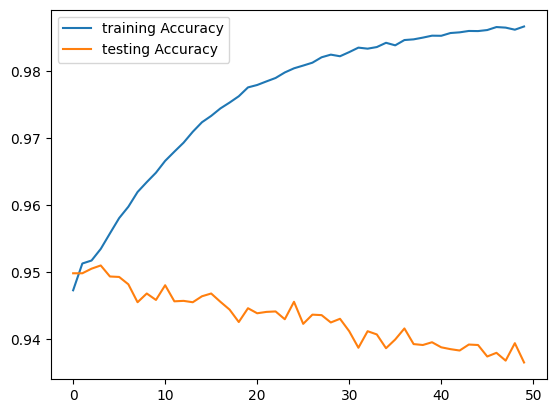

In [42]:
sns.lineplot(x=model.history.epoch,y=model.history.history['accuracy'],label='training Accuracy')

sns.lineplot(x=model.history.epoch,y=model.history.history['val_accuracy'],label='testing Accuracy')



In [43]:
df['Is Laundering'].value_counts()

Is Laundering
0    69205
1     3565
Name: count, dtype: int64

In [44]:
from imblearn.over_sampling import SMOTE

In [45]:
smote=SMOTE(random_state=21)

xtrain_res,ytrain_res=smote.fit_resample(xtrain,ytrain)

In [46]:
print('before smote',ytrain.value_counts())
print('After Sote',ytrain_res.value_counts())

before smote Is Laundering
0    55381
1     2835
Name: count, dtype: int64
After Sote Is Laundering
0    55381
1    55381
Name: count, dtype: int64


In [47]:
import optuna
from keras.layers import Dropout,BatchNormalization
from keras.regularizers import l1_l2
from keras.optimizers import Adam

def objective(trail):
    lr_rate=trail.suggest_float('learning rate',1.e-4,1.e-2,log=True)
    n_layers=trail.suggest_int('n layers',1,10)
    epochs=trail.suggest_int('epochs',1,10)
    optimizers=trail.suggest_categorical('optimizer',['Adam','RMSprop','SGD'])
    activation=trail.suggest_categorical('activation',['tanh','relu'])


    model=Sequential()
    model.add(Input(shape=(xtrain_res.shape[1],)))

    
    for i in range(n_layers):
        units=trail.suggest_int(f'units{i}',1,120)
        dropout=trail.suggest_float(f'dropout{i}',0.0,0.5)
        regu=trail.suggest_float(f'regularization{i}',1.e-4,1.e-2)
        
        model.add(Dense(units,activation=activation,kernel_regularizer=l1_l2(l1=regu,l2=regu)))
        
        model.add(Dropout(dropout))
        model.add(BatchNormalization())

    model.add(Dense(1,activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=lr_rate),loss='binary_crossentropy',metrics=['recall'])

    model.fit(xtrain_res,ytrain_res,epochs=5,batch_size=234,validation_data=(xtest,ytest))

    return max(model.history.history['recall'])

In [48]:
study=optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=5)

[I 2026-06-06 13:48:50,168] A new study created in memory with name: no-name-eb79f451-8929-4ab2-bd3a-689b89ee46ac


Epoch 1/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 1.3830 - recall: 0.9562 - val_loss: 1.1323 - val_recall: 0.7411
Epoch 2/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.1647 - recall: 0.9624 - val_loss: 1.1386 - val_recall: 0.9192
Epoch 3/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1.1426 - recall: 0.9643 - val_loss: 1.1282 - val_recall: 0.9110
Epoch 4/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.1298 - recall: 0.9652 - val_loss: 1.1575 - val_recall: 0.9247
Epoch 5/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.1328 - recall: 0.9640 - val_loss: 1.2739 - val_recall: 0.9671


[I 2026-06-06 13:49:11,249] Trial 0 finished with value: 0.9651504755020142 and parameters: {'learning rate': 0.006250699939550064, 'n layers': 1, 'epochs': 2, 'optimizer': 'RMSprop', 'activation': 'tanh', 'units0': 45, 'dropout0': 0.11091304871207197, 'regularization0': 0.002966976830571604}. Best is trial 0 with value: 0.9651504755020142.


Epoch 1/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - loss: 6.3494 - recall: 0.9642 - val_loss: 4.8198 - val_recall: 0.9671
Epoch 2/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 4.7701 - recall: 0.9781 - val_loss: 4.4693 - val_recall: 0.9932
Epoch 3/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 4.6967 - recall: 0.9838 - val_loss: 4.4445 - val_recall: 0.9932
Epoch 4/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 4.6948 - recall: 0.9837 - val_loss: 4.5265 - val_recall: 0.9918
Epoch 5/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 4.6481 - recall: 0.9873 - val_loss: 4.6222 - val_recall: 0.9795


[I 2026-06-06 13:49:55,803] Trial 1 finished with value: 0.9873422384262085 and parameters: {'learning rate': 0.007799153693062032, 'n layers': 7, 'epochs': 7, 'optimizer': 'SGD', 'activation': 'relu', 'units0': 97, 'dropout0': 0.11587423838613048, 'regularization0': 0.005935077534802035, 'units1': 114, 'dropout1': 0.36519721145273004, 'regularization1': 0.0092899851758415, 'units2': 36, 'dropout2': 0.35876029370907625, 'regularization2': 0.0068891138582211145, 'units3': 75, 'dropout3': 0.19994726861467266, 'regularization3': 0.005597932028275831, 'units4': 16, 'dropout4': 0.3363256249551925, 'regularization4': 0.008520628064853292, 'units5': 45, 'dropout5': 0.32213409912462676, 'regularization5': 0.0025351419175648833, 'units6': 65, 'dropout6': 0.2774138907380341, 'regularization6': 0.006322403466725908}. Best is trial 1 with value: 0.9873422384262085.


Epoch 1/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 7.5362 - recall: 0.8938 - val_loss: 2.1435 - val_recall: 0.6973
Epoch 2/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 1.1754 - recall: 0.9486 - val_loss: 0.6146 - val_recall: 0.9096
Epoch 3/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.5959 - recall: 0.9632 - val_loss: 0.6599 - val_recall: 0.9575
Epoch 4/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.5420 - recall: 0.9680 - val_loss: 0.5628 - val_recall: 0.8918
Epoch 5/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.5260 - recall: 0.9679 - val_loss: 0.5430 - val_recall: 0.8603


[I 2026-06-06 13:50:29,339] Trial 2 finished with value: 0.9680215120315552 and parameters: {'learning rate': 0.0002281293060834973, 'n layers': 3, 'epochs': 5, 'optimizer': 'RMSprop', 'activation': 'tanh', 'units0': 94, 'dropout0': 0.495457411834724, 'regularization0': 0.002564282967888326, 'units1': 93, 'dropout1': 0.1626978402218111, 'regularization1': 0.008459728893211506, 'units2': 86, 'dropout2': 0.484981112782654, 'regularization2': 0.00017752891776381138}. Best is trial 1 with value: 0.9873422384262085.


Epoch 1/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 7.4312 - recall: 0.6918 - val_loss: 3.2617 - val_recall: 0.7959
Epoch 2/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 2.5950 - recall: 0.9272 - val_loss: 2.0939 - val_recall: 0.9671
Epoch 3/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.7035 - recall: 0.9637 - val_loss: 1.3611 - val_recall: 0.9699
Epoch 4/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.1073 - recall: 0.9815 - val_loss: 0.9182 - val_recall: 0.9726
Epoch 5/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.7411 - recall: 0.9854 - val_loss: 0.6444 - val_recall: 0.9534


[I 2026-06-06 13:50:53,533] Trial 3 finished with value: 0.9853559732437134 and parameters: {'learning rate': 0.00010488384943983177, 'n layers': 3, 'epochs': 10, 'optimizer': 'RMSprop', 'activation': 'relu', 'units0': 20, 'dropout0': 0.40878650957734086, 'regularization0': 0.007469001655822994, 'units1': 40, 'dropout1': 0.16501912569460309, 'regularization1': 0.0049639309133316725, 'units2': 79, 'dropout2': 0.04499816166261883, 'regularization2': 0.007019292318763423}. Best is trial 1 with value: 0.9873422384262085.


Epoch 1/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - loss: 23.8567 - recall: 0.4623 - val_loss: 14.5767 - val_recall: 0.0000e+00
Epoch 2/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 11.0381 - recall: 0.5525 - val_loss: 7.5333 - val_recall: 0.0000e+00
Epoch 3/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 5.5645 - recall: 0.8476 - val_loss: 3.7532 - val_recall: 0.1014
Epoch 4/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 2.7831 - recall: 0.9532 - val_loss: 1.9536 - val_recall: 0.4808
Epoch 5/5
474/474 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 1.5583 - recall: 0.9745 - val_loss: 1.0562 - val_recall: 0.6096


[I 2026-06-06 13:51:46,391] Trial 4 finished with value: 0.9745399951934814 and parameters: {'learning rate': 0.00020696109055742462, 'n layers': 10, 'epochs': 8, 'optimizer': 'Adam', 'activation': 'relu', 'units0': 79, 'dropout0': 0.12037134111091385, 'regularization0': 0.004313658194110443, 'units1': 110, 'dropout1': 0.46229371810954173, 'regularization1': 0.007707875577159438, 'units2': 89, 'dropout2': 0.08918772304222783, 'regularization2': 0.005507140696268475, 'units3': 82, 'dropout3': 0.4029373867909952, 'regularization3': 0.0018158281629985025, 'units4': 45, 'dropout4': 0.40844410439368517, 'regularization4': 0.003528986837799749, 'units5': 55, 'dropout5': 0.41393348589467927, 'regularization5': 0.0015457493861594758, 'units6': 26, 'dropout6': 0.15007063433542328, 'regularization6': 0.007642081832855977, 'units7': 67, 'dropout7': 0.35906317649460806, 'regularization7': 0.004923174308807736, 'units8': 28, 'dropout8': 0.24300820993926636, 'regularization8': 0.008067547932338307, 

In [49]:
study.best_params

{'learning rate': 0.007799153693062032,
 'n layers': 7,
 'epochs': 7,
 'optimizer': 'SGD',
 'activation': 'relu',
 'units0': 97,
 'dropout0': 0.11587423838613048,
 'regularization0': 0.005935077534802035,
 'units1': 114,
 'dropout1': 0.36519721145273004,
 'regularization1': 0.0092899851758415,
 'units2': 36,
 'dropout2': 0.35876029370907625,
 'regularization2': 0.0068891138582211145,
 'units3': 75,
 'dropout3': 0.19994726861467266,
 'regularization3': 0.005597932028275831,
 'units4': 16,
 'dropout4': 0.3363256249551925,
 'regularization4': 0.008520628064853292,
 'units5': 45,
 'dropout5': 0.32213409912462676,
 'regularization5': 0.0025351419175648833,
 'units6': 65,
 'dropout6': 0.2774138907380341,
 'regularization6': 0.006322403466725908}

In [50]:
model=Sequential()

model.add(Input(shape=(xtrain_res.shape[1],)))
model.add(Dense(58,activation='relu',kernel_regularizer=l1_l2(l1=0.0089,l2=0.0089)))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(Dense(35,activation='relu',kernel_regularizer=l1_l2(l1=0.0097,l2=0.0097)))
model.add(Dropout( 0.12))
model.add(BatchNormalization())

model.add(Dense(1,activation='sigmoid'))

In [51]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                     │ (None, 58)                  │         403,564 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 58)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_24               │ (None, 58)                  │             232 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 35)                  │           2,065 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 35)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_25               │ (None, 35)                  │             140 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 1)                   │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 406,037 (1.55 MB)

 Trainable params: 405,851 (1.55 MB)

 Non-trainable params: 186 (744.00 B)

In [52]:
from keras.optimizers import RMSprop
model.compile(optimizer=RMSprop(learning_rate= 0.00037),loss='binary_crossentropy',metrics=['recall'])

model.fit(xtrain_res,ytrain_res,epochs=10,batch_size=234,validation_data=(xtest,ytest))

Epoch 1/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 4.8525 - recall: 0.9207 - val_loss: 1.4373 - val_recall: 0.0110
Epoch 2/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.1051 - recall: 0.9765 - val_loss: 0.9601 - val_recall: 0.9329
Epoch 3/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.9992 - recall: 0.9820 - val_loss: 0.9809 - val_recall: 0.9562
Epoch 4/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.9949 - recall: 0.9812 - val_loss: 0.9984 - val_recall: 0.9521
Epoch 5/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.9922 - recall: 0.9813 - val_loss: 1.0157 - val_recall: 0.9425
Epoch 6/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.9901 - recall: 0.9815 - val_loss: 1.0514 - val_recall: 0.9699
Epoch 7/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.9903 - recall: 0.9804 - val_loss: 1.0188 - val_recall: 0.9712
Epoch 8/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.9882 - recall: 0.9799 - val_loss: 1.0512 - val_recall: 0.9658
Epoch 9/

In [53]:
from sklearn.metrics import classification_report

ypred=np.where(model.predict(xtest)>0.5,1,0)



455/455 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [54]:
print('classification_report\n',classification_report(ytest,ypred))

classification_report
               precision    recall  f1-score   support

           0       1.00      0.79      0.88     13824
           1       0.20      0.98      0.33       730

    accuracy                           0.80     14554
   macro avg       0.60      0.88      0.61     14554
weighted avg       0.96      0.80      0.86     14554



In [55]:
import pickle 

with open(r"C:\Users\rithi\OneDrive\Desktop\Inno\ANN\preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\DELL\\450_456_460 recomend\\ANN\\preprocessor.pkl'

In [ ]:
model.save(r"C:\Users\rithi\OneDrive\Desktop\Inno\ANN\model.keras")

In [ ]:
from keras.models import load_model

In [ ]:
model=load_model(r"C:\Users\rithi\OneDrive\Desktop\Inno\ANN\model.keras")